In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets.packaged_modules.webdataset.webdataset import torch_loads
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from torch.utils.data import TensorDataset, DataLoader

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [2]:
from examples.case_studies.sc_GEM_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [3]:
len(labels)

224

In [4]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(data == 0, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [5]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 59
After remove all nan 34
After remove all zeros 33
Input #cols 59
After remove all nan 27
After remove all zeros 27


Text(0.5, 1.0, 'methylation_data_clean')

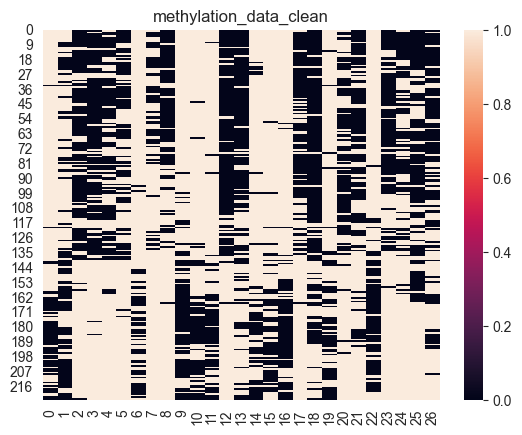

In [6]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

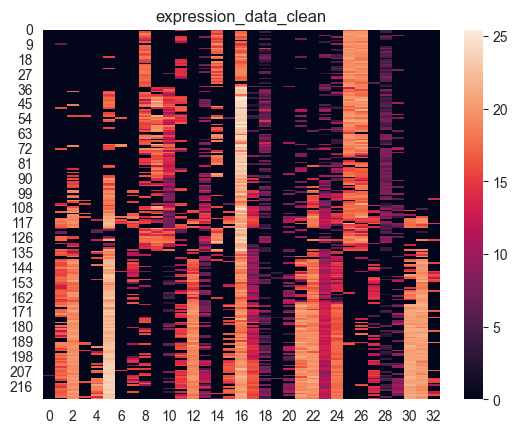

In [7]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [8]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [9]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [10]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3023, 3), (3023,), (3782, 3), (3782,))

In [11]:
expression_edges.max(0), methylation_edges.max(0)

(array([223,  32,   0]), array([223,  59,   1]))

In [12]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [13]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [14]:
edges.shape, weights.shape

((6805, 3), (6805,))

In [15]:
np.any(weights == 0)

False

In [16]:
save_edges_and_weights('./data/sc_GEM', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [17]:
train_data = np.load('./data/sc_GEM/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sc_GEM/test_data.npz', allow_pickle=True)

In [18]:
train_data['nums_type']

array([224,  60,   2])

!python hgnn/main_torch_zinb.py --data sc_GEM --feature adj --loss gauss --iter 50

## Analysis

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from torch.utils.data import TensorDataset, DataLoader

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [20]:
cell_embeddings = np.load('./embeddings/sc_GEM/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/sc_GEM/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/sc_GEM/mymodel_2.npy', allow_pickle=True)


In [21]:
cell_embeddings.shape

(224, 64)

{'NMI': 0.5164129296289204,
 'ARI': 0.3870812308387961,
 'FMI': 0.47049858159114266}

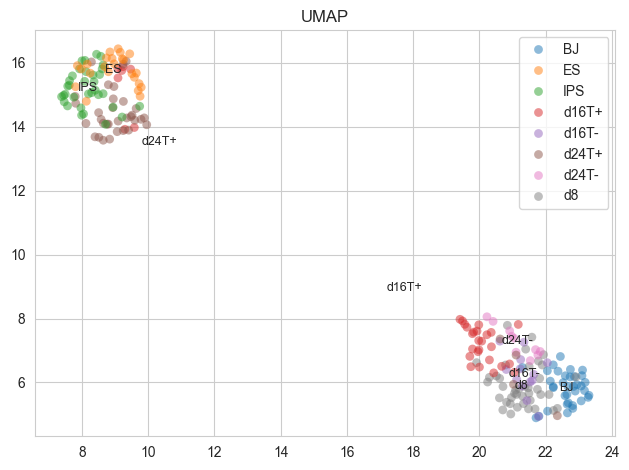

In [22]:
umap_visualize(cell_embeddings, labels)

In [23]:
!mkdir -p ./embeddings/hgnn/sc_GEM

In [24]:
!mv ./*.npy ./embeddings/hgnn/sc_GEM


zsh:1: no matches found: ./*.npy


<Axes: >

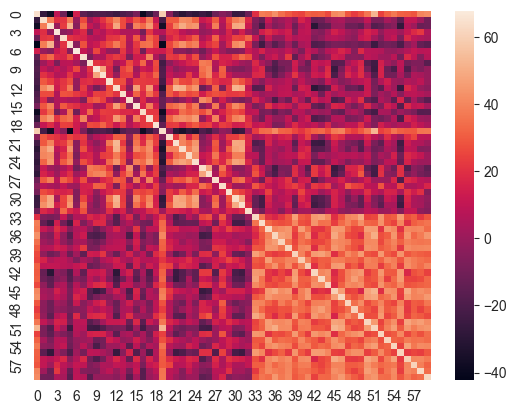

In [25]:
sns.heatmap(gene_embeddings @ gene_embeddings.T)

<Axes: >

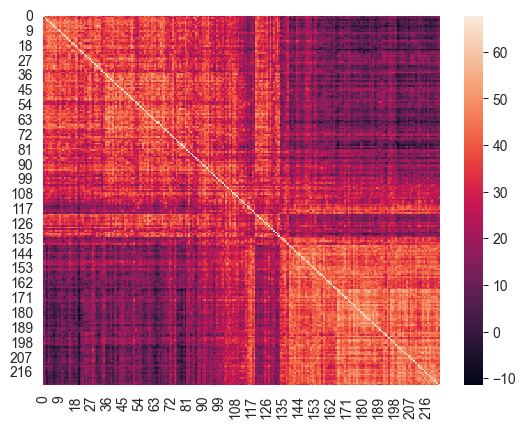

In [26]:
sns.heatmap(cell_embeddings @ cell_embeddings.T)

In [27]:
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.optim import Adam
from torch.nn.functional import mse_loss, relu
import torch.nn.functional as F
import torch

In [102]:
class PhasingModel(nn.Module):

    def __init__(self, embed_dim, activations, omics_offset):
        super().__init__()
        self.omics_offset = omics_offset
        self.activations = activations

        self.fc_gene_p = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.fc_gene_m = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, G, C, O):
        act1, act2 = self.activations
        latent_p = self.fc_gene_p(G)
        latent_m = self.fc_gene_m(G)
        p_o1, p_o2 = C @ (latent_p + O[0]).T, C @ (latent_p + O[1]).T
        m_o1, m_o2 = C @ (latent_m + O[0]).T, C @ (latent_m + O[1]).T

        Xp = torch.cat([act1(p_o1[:, 0:self.omics_offset]), act2(p_o2[:, self.omics_offset:])], dim=1)
        Xm = torch.cat([act1(m_o1[:, 0:self.omics_offset]), act2(m_o2[:, self.omics_offset:])], dim=1)
        return Xp, Xm

    @torch.no_grad()
    def predict(self, G, C, O):
        Xp, Xm = self.forward(G, C, O)
        return Xp.cpu().numpy(), Xm.cpu().numpy()

    def reconstruct(self, G, C, O):
        Xp, Xm = self.forward(G, C, O)
        return Xp + Xm


In [97]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X = torch.tensor(np.concatenate([expression_data_clean, methylation_data_clean], axis=1), dtype=torch.float)

In [30]:
from torch.nn.functional import cosine_similarity, softmax
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph

# 1. 由细胞嵌入 C 构建 kNN 图拉普拉斯（最简单）
def build_laplacian(C_np, k=10, sigma=1.0):
    """
    C_np: (n_cells, embed_dim) 的 numpy 数组
    返回: (n_cells, n_cells) 的稀疏 FloatTensor
    """
    adj = kneighbors_graph(C_np, k, mode='distance', metric='sqeuclidean', include_self=False).toarray()
    adj = np.exp(-adj / (2 * sigma ** 2))          # 高斯核
    lap = csgraph.laplacian(adj, normed=True)      # 归一化拉普拉斯
    return torch.tensor(lap, dtype=torch.float)

In [56]:
def regularizers(xp, xm, lap, l1=1e-4, diff=1e-3, smooth=1e-2, ent=1e-2):
    """
    xp, xm: (batch_size, n_genes) 当前 batch 的输出
    lap:    (batch_size, batch_size) 预先算好的子图拉普拉斯子矩阵
    返回: 4 个标量 loss 分量
    """
    # 1. L1 稀疏
    sparse = xp.sum() + xm.sum()

    # 2. 余弦相似度（负值 => 鼓励差异）
    cos_sim = cosine_similarity(xp, xm, dim=1).mean()
    diff_loss = -cos_sim

    # 3. 图平滑  Tr(X^T L X)
    smooth_p = torch.trace(xp.T @ lap @ xp) / xp.shape[0]
    smooth_m = torch.trace(xm.T @ lap @ xm) / xm.shape[0]
    smooth_loss = smooth_p + smooth_m

    # 4. 熵平衡（逐细胞）
    norm_p = xp.norm(p=1, dim=1) + 1e-8
    norm_m = xm.norm(p=1, dim=1) + 1e-8
    alpha = norm_p / (norm_p + norm_m)
    entropy = -(alpha * alpha.log() + (1 - alpha) * (1 - alpha).log())
    ent_loss = entropy.mean()

    return l1 * sparse, diff * diff_loss, smooth * smooth_loss, ent * ent_loss

In [157]:
epochs = 200
model = PhasingModel(embed_dim=X.shape[1], activations=[F.softplus, F.sigmoid], omics_offset=expression_data_clean.shape[1])
optimizer = Adam(model.parameters(), lr=1e-2)
history = []
cell_dataset = TensorDataset(C, X)
dataloader = DataLoader(cell_dataset, shuffle=True, batch_size=256)

# 超参，按需要调
lambda_sparse  = 0
lambda_diff    = 0
lambda_smooth  = 0
lambda_ent     = 0

history = []
for epoch in range(epochs):
    epoch_loss, epoch_rec, epoch_reg = 0., 0., 0.
    for c_batch, x_batch in dataloader:
        c_batch, x_batch = c_batch.to(C.device), x_batch.to(C.device)

        xp, xm = model(G, x_batch, O)                # 前向
        x_hat = xp + xm
        loss_rec = mse_loss(x_hat, x_batch)

        lap_batch = build_laplacian(x_batch.cpu().numpy(), k=10).to(C.device)   # 放到 GPU

        reg_sparse, reg_diff, reg_smooth, reg_ent = regularizers(
            xp, xm, lap_batch,
            l1=lambda_sparse, diff=lambda_diff,
            smooth=lambda_smooth, ent=lambda_ent)

        loss = loss_rec + reg_sparse + reg_diff + reg_smooth + reg_ent

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_rec  += loss_rec.item()
        epoch_reg  += (reg_sparse - reg_diff + reg_smooth + reg_ent).item()

    history.append(epoch_loss)
    if epoch % 1 == 0:
        print(f'Epoch {epoch:3d}  total={epoch_loss:.3f}  rec={epoch_rec:.3f}  reg={epoch_reg:.3f}')

plt.plot(history)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (60x64 and 60x60)

In [152]:
Xp, Xm = model.predict(G, C, O)

Xp_expression, Xp_methylation = Xp[:, :expression_data_clean.shape[1]], Xp[:, expression_data_clean.shape[1]:]
Xm_expression, Xm_methylation = Xm[:, :expression_data_clean.shape[1]], Xm[:, expression_data_clean.shape[1]:]

Xp_methylation = (Xp_methylation > 0.5).astype(int)
Xm_methylation = (Xm_methylation > 0.5).astype(int)

Text(0.5, 1.0, 'X_methylation')

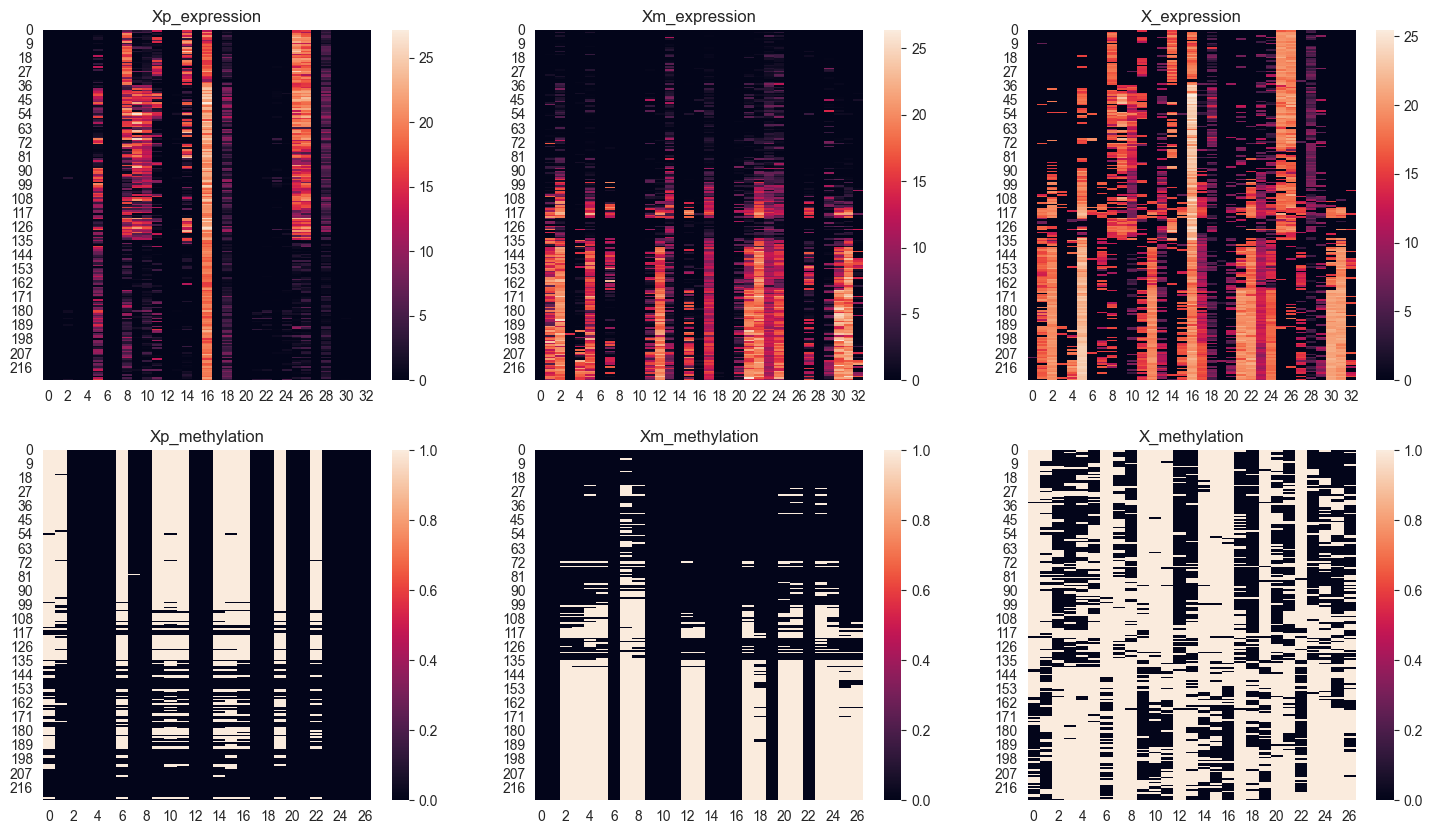

In [153]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp_expression,ax=ax)
plt.title('Xp_expression')
ax = plt.subplot(232)
sns.heatmap(Xm_expression,ax=ax)
plt.title('Xm_expression')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X_expression')
ax = plt.subplot(234)
sns.heatmap(Xp_methylation,ax=ax)
plt.title('Xp_methylation')
ax = plt.subplot(235)
sns.heatmap(Xm_methylation,ax=ax)
plt.title('Xm_methylation')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X_methylation')

{'NMI': 0.6788006480222744,
 'ARI': 0.5433509074090539,
 'FMI': 0.6120871476828441}

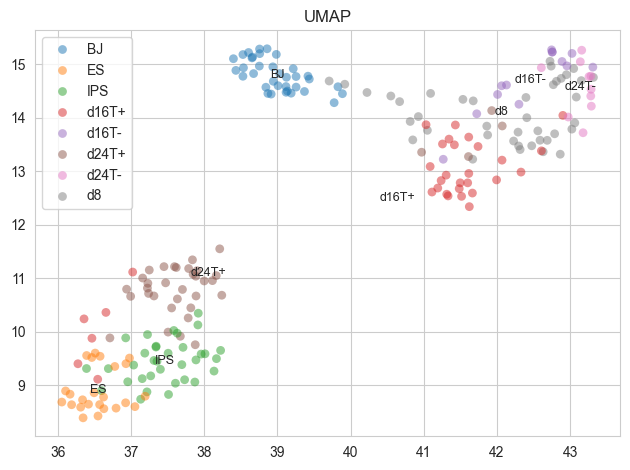

In [154]:
umap_visualize(X, labels)

{'NMI': 0.5168251870529577,
 'ARI': 0.33319526332323085,
 'FMI': 0.45457113267255844}

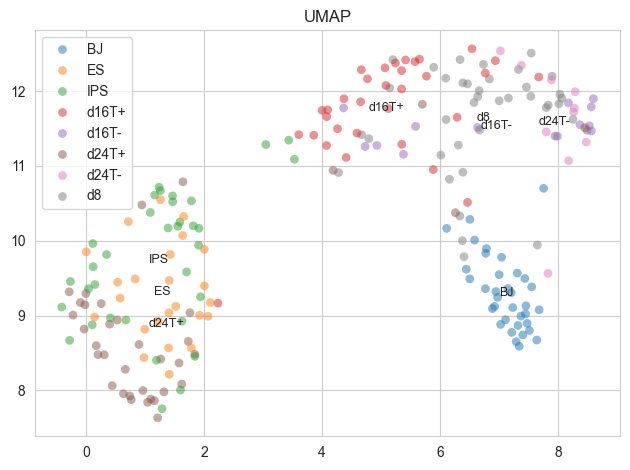

In [155]:
umap_visualize(Xp, labels)

{'NMI': 0.5147467468254113,
 'ARI': 0.30665186912434894,
 'FMI': 0.4475898319535722}

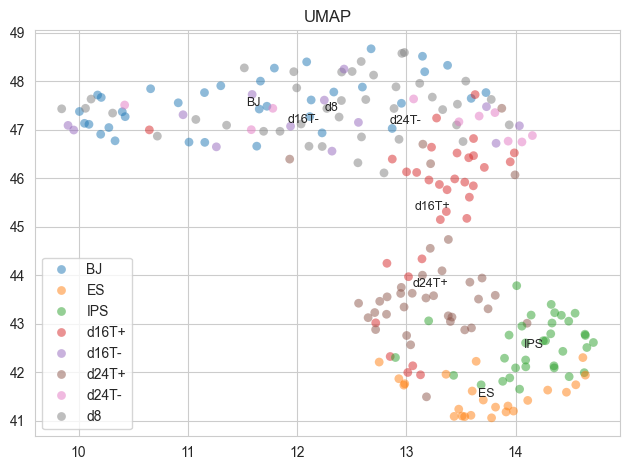

In [156]:
umap_visualize(Xm, labels)

{'NMI': 0.5198733303095593,
 'ARI': 0.32697454771834883,
 'FMI': 0.4463319398910256}

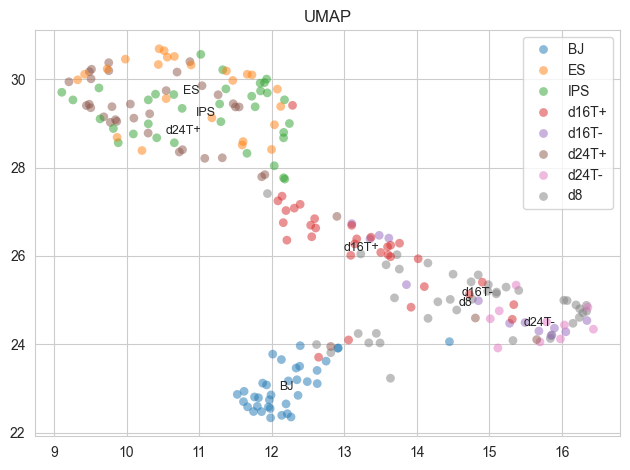

In [148]:
umap_visualize(Xp_expression, labels)

{'NMI': 0.5065171024338128,
 'ARI': 0.3152165176918804,
 'FMI': 0.41214279703288836}

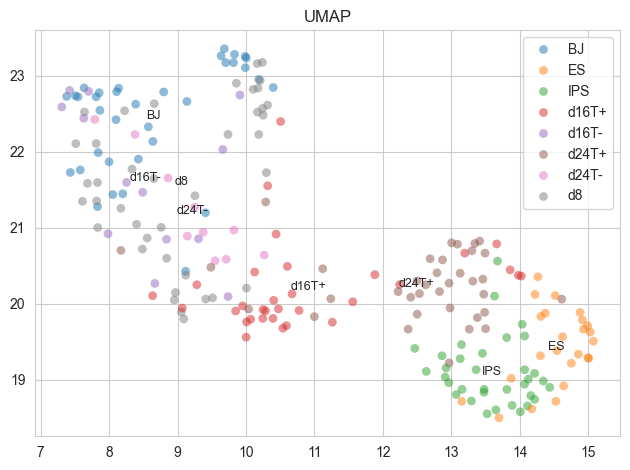

In [149]:
umap_visualize(Xm_expression, labels)

{'NMI': 0.42459292530267384,
 'ARI': 0.24347494064637326,
 'FMI': 0.3532862342132824}

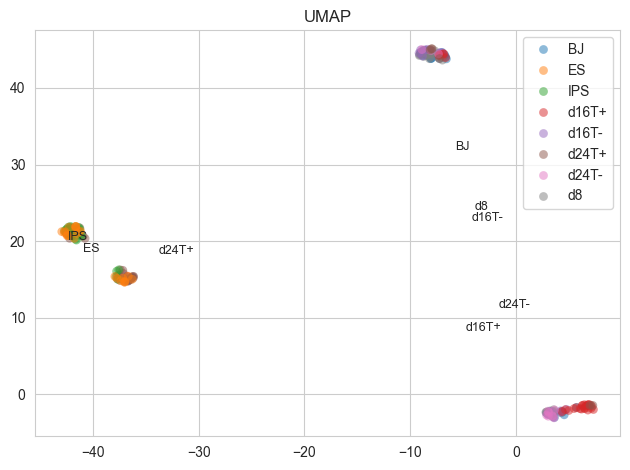

In [78]:
umap_visualize(Xp_methylation, labels)

{'NMI': 0.36949001299884654,
 'ARI': 0.20954607838658612,
 'FMI': 0.33011964824789475}

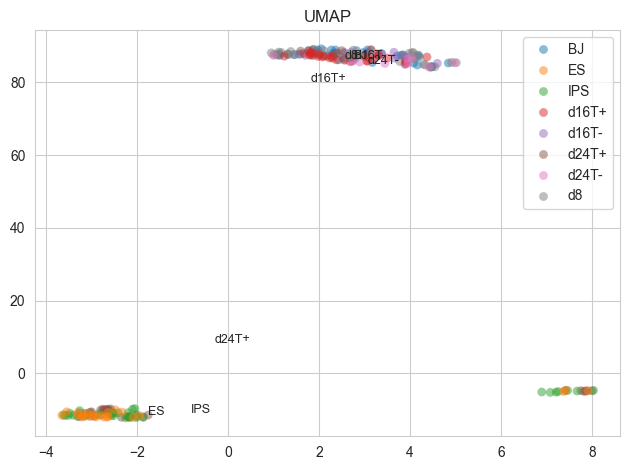

In [79]:
umap_visualize(Xm_methylation, labels)

{'NMI': 0.6528485577581006,
 'ARI': 0.5294446174755082,
 'FMI': 0.6006081194306532}

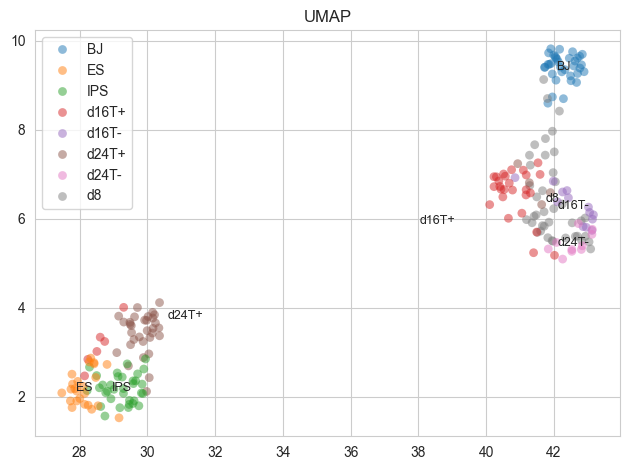

In [149]:
umap_visualize(expression_data_clean, labels)

{'NMI': 0.3960620675625873,
 'ARI': 0.22969154263335673,
 'FMI': 0.3354387259823922}

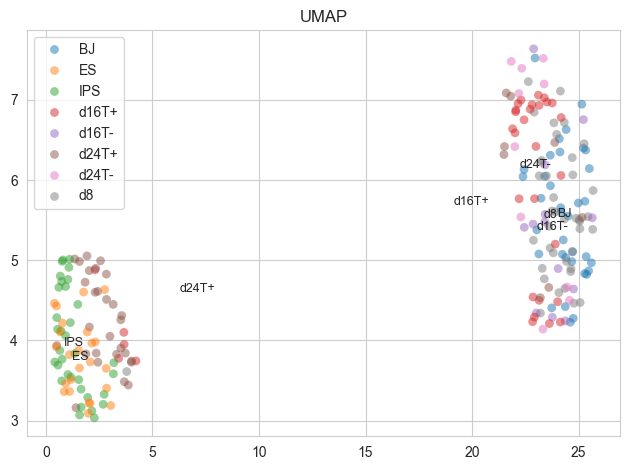

In [150]:
umap_visualize(methylation_data_clean, labels)